# E-Commerce Session Conversion Analysis

**Objective:** Analyze e-commerce browsing sessions to understand what distinguishes converting and non-converting sessions and how visitor behaviour changes across the funnel.

**Dataset:** 10,000 simulated e-commerce browsing sessions with page views, session duration, visitor type, traffic source, and purchase outcome.

---
## 1. Data Loading, Cleaning & Validation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('data/ecommerce_sessions.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (10000, 15)


,session_id,visitor_type,traffic_source,region,device_type,page_views,session_duration,bounce,product_pages_viewed,cart_additions,day_of_week,hour,month,is_special_day,revenue
0,S00001,New_Visitor,Direct,Asia,Mobile,6.0,754.9,False,2,0,Wednesday,19,Oct,True,0.00
1,S00002,Returning_Visitor,Direct,North America,Mobile,1.0,142.6,True,0,0,Monday,13,Nov,False,0.00
2,S00003,Returning_Visitor,Organic,Europe,Tablet,9.0,256.7,False,3,1,Monday,9,Jul,False,25.62
3,S00004,Returning_Visitor,Referral,Asia,Desktop,6.0,94.9,False,2,1,Tuesday,17,Apr,False,0.00
4,S00005,New_Visitor,Direct,Europe,Mobile,8.0,102.1,False,3,0,Tuesday,12,May,False,0.00


In [2]:
print("=== Dataset Info ===")
print(f"Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}")
print(f"\nColumn types:\n{df.dtypes}")
print(f"\n=== Missing Values ===\n{df.isnull().sum()}")
print(f"\n=== Duplicates: {df.duplicated().sum()} ===")
print(f"\n=== Numerical Summary ===")
df.describe()

=== Dataset Info ===
Rows: 10,000  |  Columns: 15

Column types:
session_id                  str
visitor_type                str
traffic_source              str
region                      str
device_type                 str
page_views              float64
session_duration        float64
bounce                     bool
product_pages_viewed      int64
cart_additions            int64
day_of_week                 str
hour                      int64
month                       str
is_special_day             bool
revenue                 float64
dtype: object

=== Missing Values ===
session_id                0
visitor_type              0
traffic_source            0
region                    0
device_type               0
page_views              150
session_duration        150
bounce                    0
product_pages_viewed      0
cart_additions            0
day_of_week               0
hour                      0
month                     0
is_special_day            0
revenue                  

,page_views,session_duration,product_pages_viewed,cart_additions,hour,revenue
count,9850.000000,9850.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,3.549543,204.808081,1.013100,0.254600,13.655200,2.398806
std,2.975384,288.073330,1.388136,0.554626,5.052907,13.566408
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,36.600000,0.000000,0.000000,10.000000,0.000000
50%,3.000000,97.300000,1.000000,0.000000,14.000000,0.000000
75%,5.000000,243.900000,2.000000,0.000000,18.000000,0.000000
max,30.000000,1800.000000,10.000000,5.000000,23.000000,413.380000


### 1.1 Handle Missing Values & Validate Fields

In [3]:
# Fill missing page_views with median, session_duration with median
df['page_views'] = df['page_views'].fillna(df['page_views'].median())
df['session_duration'] = df['session_duration'].fillna(df['session_duration'].median())

# Validate ranges
assert (df['page_views'] >= 1).all(), "page_views has values < 1"
assert (df['session_duration'] >= 0).all(), "session_duration has negative values"
assert (df['revenue'] >= 0).all(), "revenue has negative values"

# Fix dtypes
df['page_views'] = df['page_views'].astype(int)
df['hour'] = df['hour'].astype(int)
df['bounce'] = df['bounce'].astype(bool)
df['is_special_day'] = df['is_special_day'].astype(bool)

# Derived columns
df['is_converted'] = (df['revenue'] > 0).astype(int)
df['duration_minutes'] = round(df['session_duration'] / 60, 2)
df['engagement_score'] = (
    df['page_views'] * 0.3 +
    df['product_pages_viewed'] * 0.4 +
    df['cart_additions'] * 0.3
).round(2)

# Order months and days properly
month_order = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
df['month'] = pd.Categorical(df['month'], categories=month_order, ordered=True)
df['day_of_week'] = pd.Categorical(df['day_of_week'], categories=day_order, ordered=True)

print(f"Missing values after cleaning: {df.isnull().sum().sum()}")
print(f"Conversion rate: {df['is_converted'].mean():.2%}")
print(f"\nNew columns added: is_converted, duration_minutes, engagement_score")
df[['session_id','page_views','session_duration','duration_minutes','engagement_score','is_converted']].head(10)

Missing values after cleaning: 0
Conversion rate: 5.64%

New columns added: is_converted, duration_minutes, engagement_score


,session_id,page_views,session_duration,duration_minutes,engagement_score,is_converted
0,S00001,6,754.9,12.58,2.6,0
1,S00002,1,142.6,2.38,0.3,0
2,S00003,9,256.7,4.28,4.2,1
3,S00004,6,94.9,1.58,2.9,0
4,S00005,8,102.1,1.70,3.6,0
5,S00006,2,256.4,4.27,0.6,0
6,S00007,2,31.6,0.53,1.0,0
7,S00008,2,90.8,1.51,1.3,0
8,S00009,1,24.2,0.40,0.3,0
9,S00010,2,82.9,1.38,1.0,1


---
## 2. Exploratory Data Analysis — Visitor Behaviour

### 2.1 Page Views & Session Duration Distributions

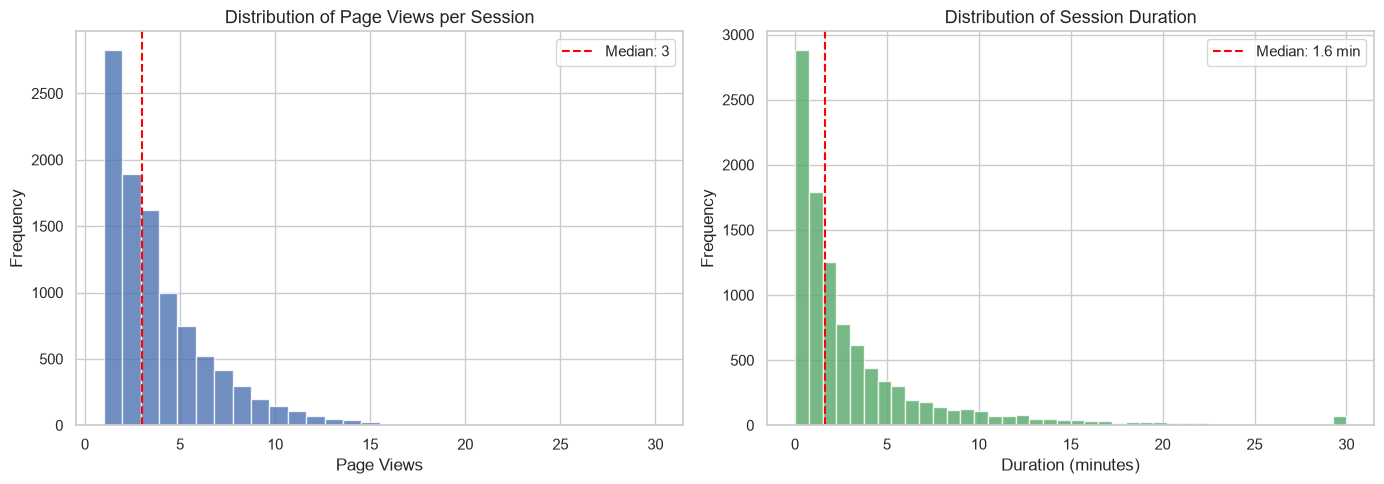

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['page_views'], bins=30, color='#4C72B0', edgecolor='white', alpha=0.8)
axes[0].axvline(df['page_views'].median(), color='red', linestyle='--', label=f"Median: {df['page_views'].median():.0f}")
axes[0].set_title('Distribution of Page Views per Session', fontsize=13)
axes[0].set_xlabel('Page Views')
axes[0].set_ylabel('Frequency')
axes[0].legend()

axes[1].hist(df['duration_minutes'], bins=40, color='#55A868', edgecolor='white', alpha=0.8)
axes[1].axvline(df['duration_minutes'].median(), color='red', linestyle='--', label=f"Median: {df['duration_minutes'].median():.1f} min")
axes[1].set_title('Distribution of Session Duration', fontsize=13)
axes[1].set_xlabel('Duration (minutes)')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.2 Conversion Rate by Visitor Type

                   sessions  conversions  conversion_rate  avg_revenue  avg_page_views  avg_duration
visitor_type                                                                                        
New_Visitor            5606          294            0.052       39.954           3.555         3.491
Returning_Visitor      4394          270            0.061       45.340           3.524         3.254


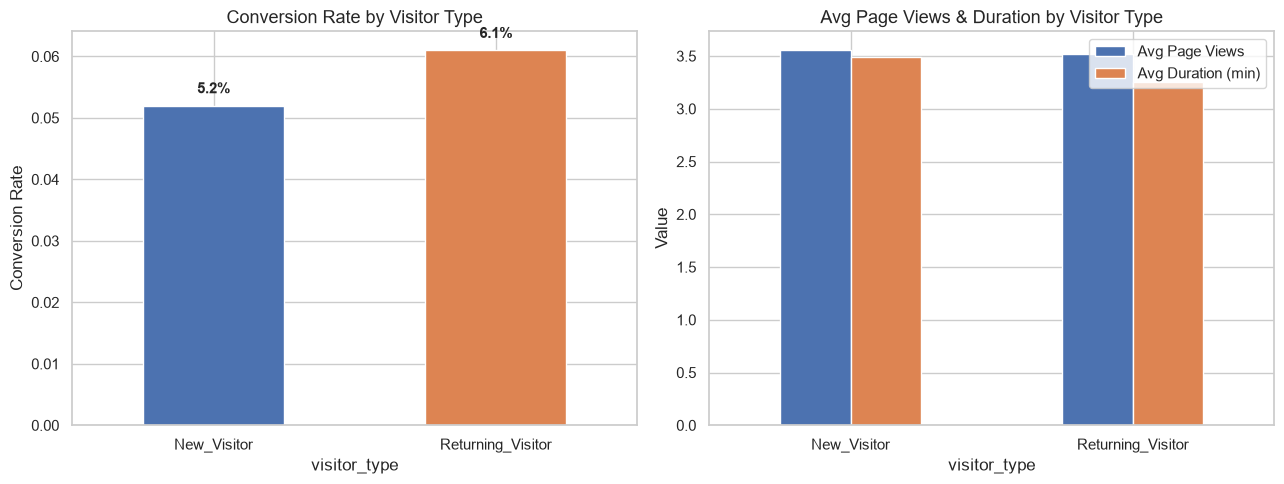

In [5]:
visitor_conv = df.groupby('visitor_type').agg(
    sessions=('session_id', 'count'),
    conversions=('is_converted', 'sum'),
    conversion_rate=('is_converted', 'mean'),
    avg_revenue=('revenue', lambda x: x[x > 0].mean() if (x > 0).any() else 0),
    avg_page_views=('page_views', 'mean'),
    avg_duration=('duration_minutes', 'mean')
).round(3)

print(visitor_conv.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors = ['#4C72B0', '#DD8452']
visitor_conv['conversion_rate'].plot(kind='bar', ax=axes[0], color=colors, edgecolor='white')
axes[0].set_title('Conversion Rate by Visitor Type', fontsize=13)
axes[0].set_ylabel('Conversion Rate')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, v in enumerate(visitor_conv['conversion_rate']):
    axes[0].text(i, v + 0.002, f'{v:.1%}', ha='center', fontsize=11, fontweight='bold')

visitor_conv[['avg_page_views', 'avg_duration']].plot(kind='bar', ax=axes[1], color=colors, edgecolor='white')
axes[1].set_title('Avg Page Views & Duration by Visitor Type', fontsize=13)
axes[1].set_ylabel('Value')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(['Avg Page Views', 'Avg Duration (min)'])

plt.tight_layout()
plt.show()

### 2.3 Conversion Rate by Traffic Source

                sessions  conversion_rate  avg_revenue  avg_engagement
traffic_source                                                        
Direct              2527            0.063       46.207           1.548
Paid                1566            0.062       40.630           1.535
Organic             2933            0.054       45.641           1.557
Referral            1468            0.052       32.651           1.516
Social              1506            0.049       40.632           1.549


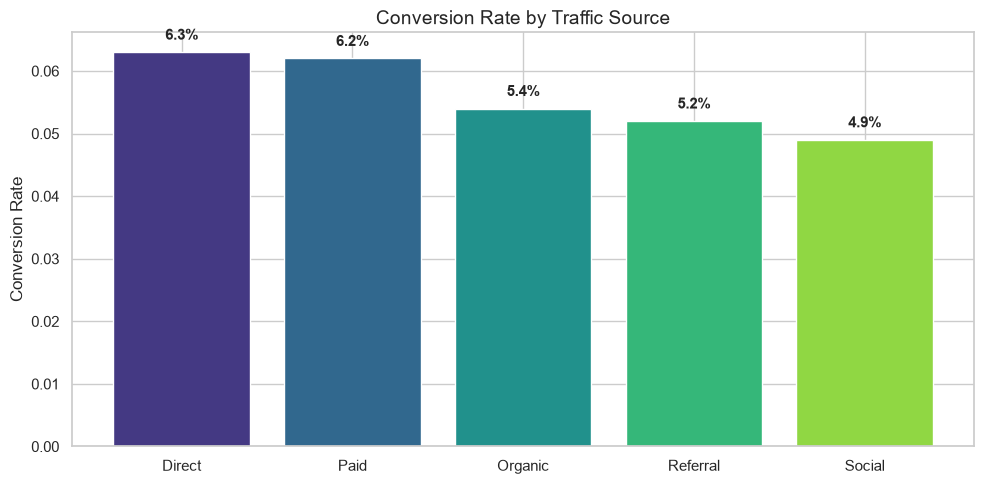

In [6]:
traffic_conv = df.groupby('traffic_source').agg(
    sessions=('session_id', 'count'),
    conversion_rate=('is_converted', 'mean'),
    avg_revenue=('revenue', lambda x: x[x > 0].mean() if (x > 0).any() else 0),
    avg_engagement=('engagement_score', 'mean')
).sort_values('conversion_rate', ascending=False).round(3)
print(traffic_conv.to_string())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(traffic_conv.index, traffic_conv['conversion_rate'],
              color=sns.color_palette('viridis', len(traffic_conv)), edgecolor='white')
ax.set_title('Conversion Rate by Traffic Source', fontsize=14)
ax.set_ylabel('Conversion Rate')
for bar, val in zip(bars, traffic_conv['conversion_rate']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
            f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.4 Converting vs Non-Converting Sessions — Behavioural Comparison

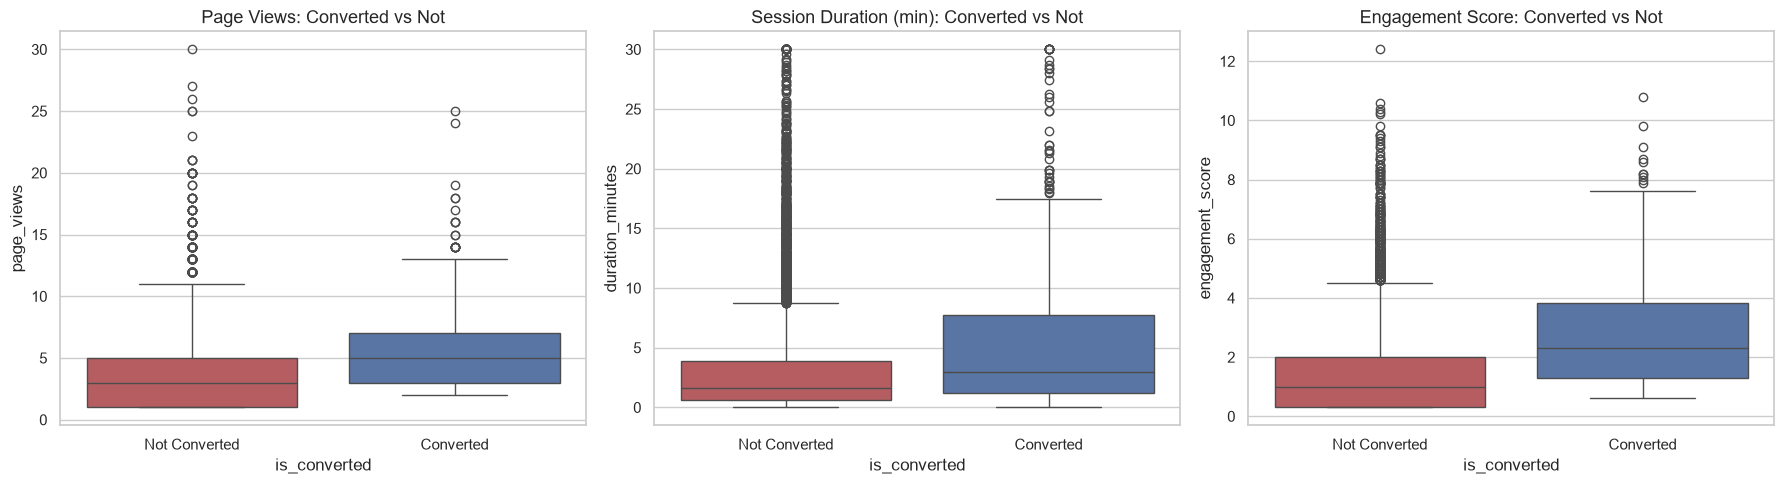


=== Mean Values: Converted vs Not Converted ===
                      Not Converted  Converted
page_views                     3.42       5.63
duration_minutes               3.26       5.56
product_pages_viewed           0.95       2.13
cart_additions                 0.22       0.78
engagement_score               1.47       2.78


In [7]:
conv_label = df['is_converted'].map({1: 'Converted', 0: 'Not Converted'})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(x=conv_label, y=df['page_views'], ax=axes[0], palette=['#C44E52', '#4C72B0'])
axes[0].set_title('Page Views: Converted vs Not', fontsize=13)

sns.boxplot(x=conv_label, y=df['duration_minutes'], ax=axes[1], palette=['#C44E52', '#4C72B0'])
axes[1].set_title('Session Duration (min): Converted vs Not', fontsize=13)

sns.boxplot(x=conv_label, y=df['engagement_score'], ax=axes[2], palette=['#C44E52', '#4C72B0'])
axes[2].set_title('Engagement Score: Converted vs Not', fontsize=13)

plt.tight_layout()
plt.show()

# Statistical summary
comp = df.groupby('is_converted')[['page_views','duration_minutes','product_pages_viewed','cart_additions','engagement_score']].mean().round(2)
comp.index = ['Not Converted', 'Converted']
print("\n=== Mean Values: Converted vs Not Converted ===")
print(comp.T.to_string())

### 2.5 Conversion by Device Type & Region

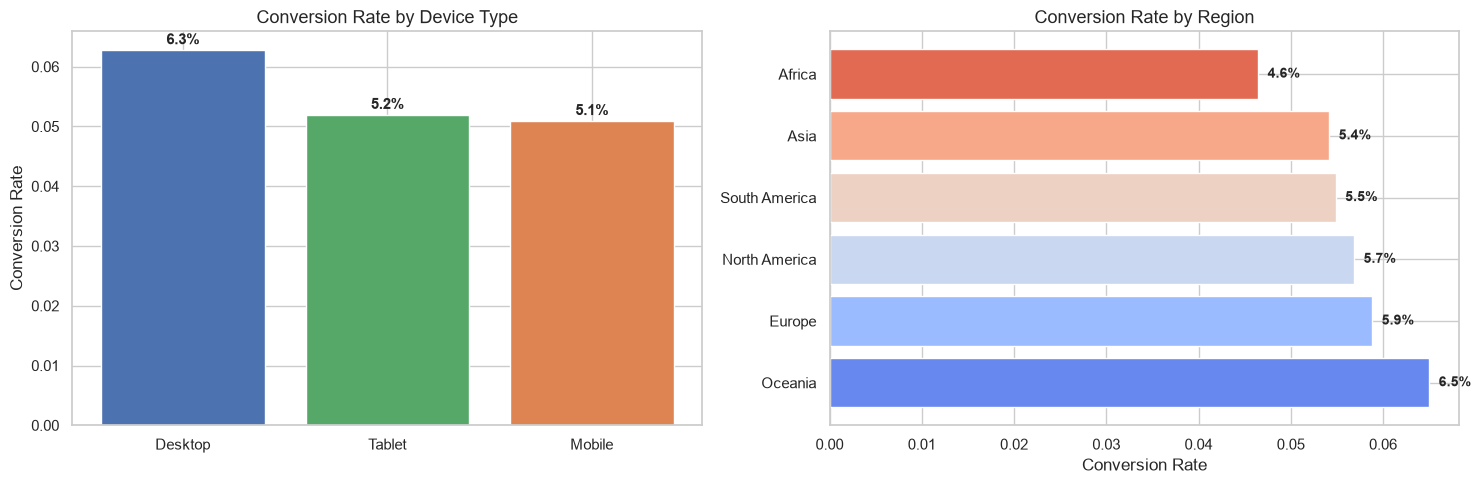

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Device
device_conv = df.groupby('device_type')['is_converted'].mean().sort_values(ascending=False)
bars = axes[0].bar(device_conv.index, device_conv.values, color=['#4C72B0','#55A868','#DD8452'], edgecolor='white')
axes[0].set_title('Conversion Rate by Device Type', fontsize=13)
axes[0].set_ylabel('Conversion Rate')
for bar, val in zip(bars, device_conv.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001, f'{val:.1%}', ha='center', fontsize=11, fontweight='bold')

# Region
region_conv = df.groupby('region')['is_converted'].mean().sort_values(ascending=False)
bars = axes[1].barh(region_conv.index, region_conv.values, color=sns.color_palette('coolwarm', len(region_conv)), edgecolor='white')
axes[1].set_title('Conversion Rate by Region', fontsize=13)
axes[1].set_xlabel('Conversion Rate')
for bar, val in zip(bars, region_conv.values):
    axes[1].text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.1%}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

### 2.6 Temporal Patterns — Hourly & Day-of-Week Heatmap

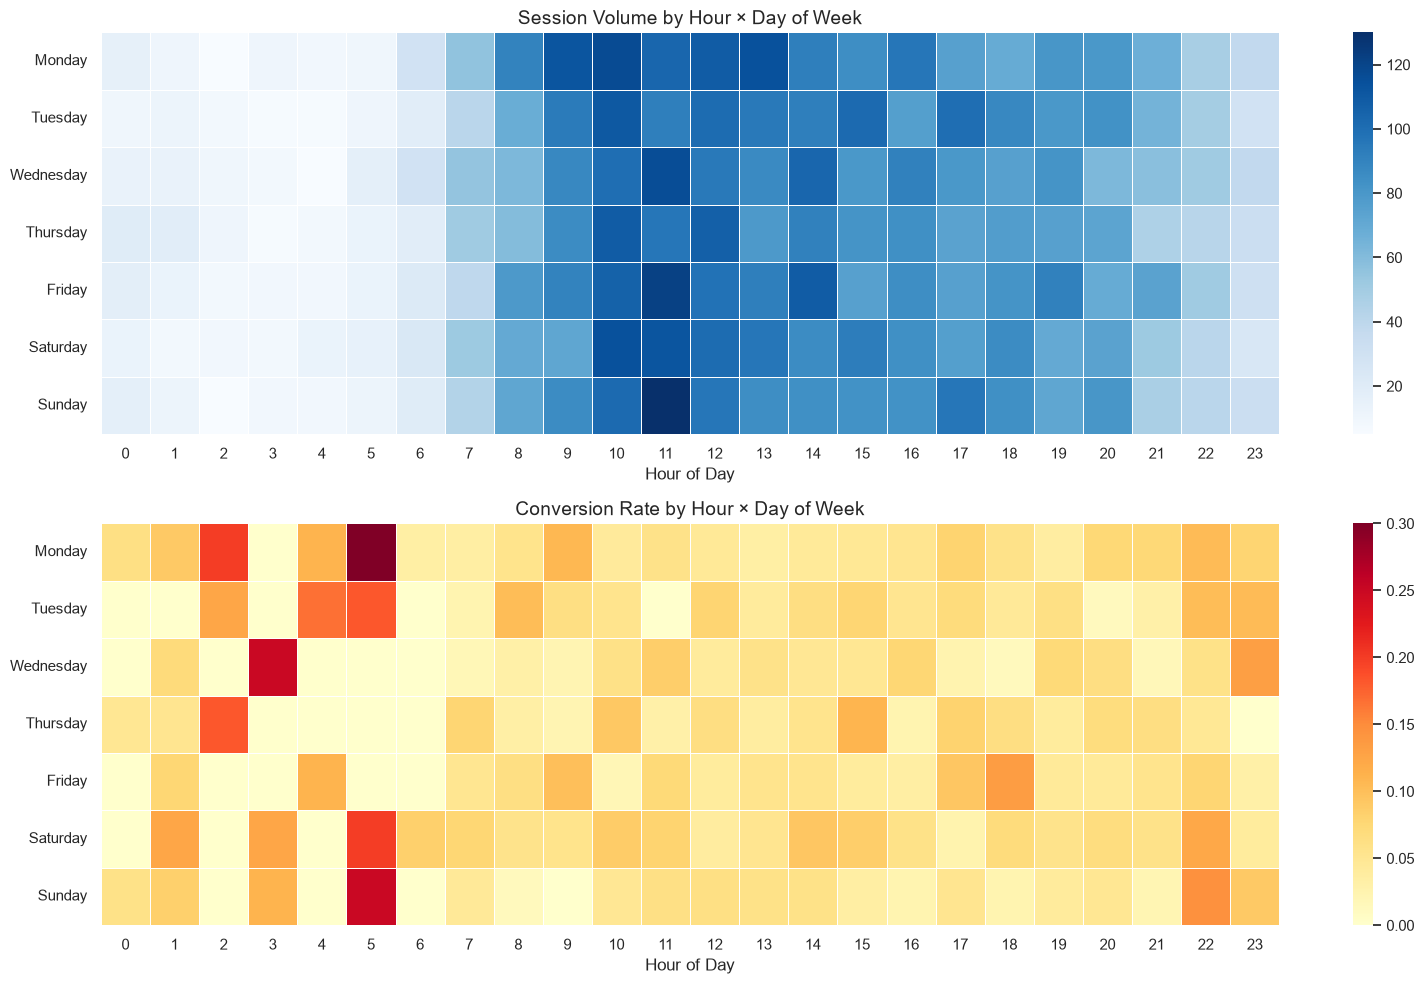

In [9]:
# Heatmap: conversion rate by hour × day_of_week
heatmap_data = df.pivot_table(values='is_converted', index='day_of_week', columns='hour', aggfunc='mean')

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Session volume heatmap
volume = df.pivot_table(values='session_id', index='day_of_week', columns='hour', aggfunc='count')
sns.heatmap(volume, cmap='Blues', annot=False, ax=axes[0], linewidths=0.5)
axes[0].set_title('Session Volume by Hour × Day of Week', fontsize=14)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('')

# Conversion rate heatmap
sns.heatmap(heatmap_data, cmap='YlOrRd', annot=False, ax=axes[1], linewidths=0.5, fmt='.1%')
axes[1].set_title('Conversion Rate by Hour × Day of Week', fontsize=14)
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### 2.7 Monthly Conversion Trend

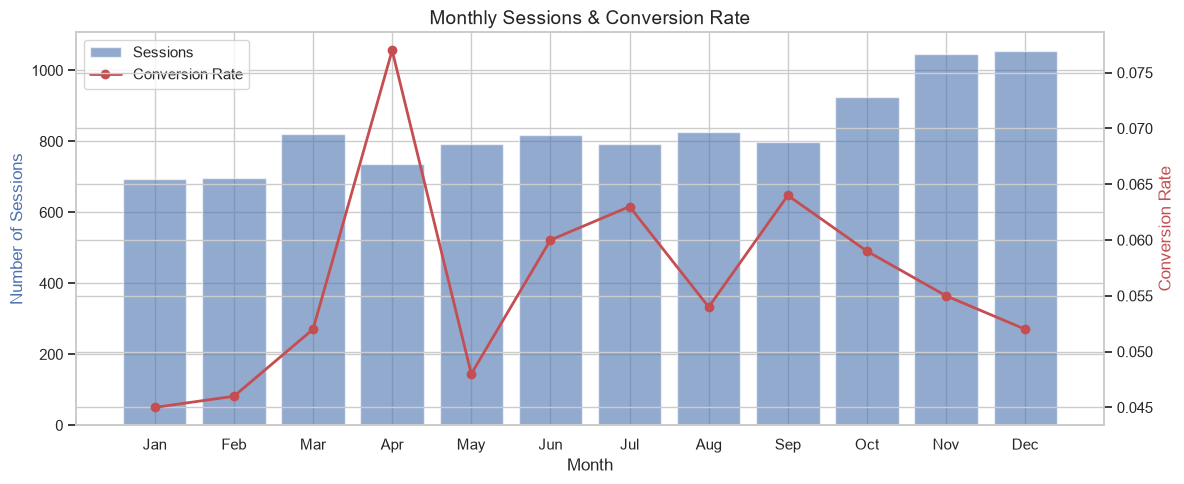

       sessions  conversions  conversion_rate  total_revenue
month                                                       
Jan         693           31            0.045        1287.91
Feb         698           32            0.046        1120.29
Mar         821           43            0.052        1730.22
Apr         736           57            0.077        2657.34
May         792           38            0.048        1832.13
Jun         818           49            0.060        2396.73
Jul         792           50            0.063        1917.74
Aug         826           45            0.054        1799.61
Sep         798           51            0.064        1839.99
Oct         925           55            0.059        2302.69
Nov        1047           58            0.055        2566.04
Dec        1054           55            0.052        2537.37


In [10]:
monthly = df.groupby('month', observed=True).agg(
    sessions=('session_id', 'count'),
    conversions=('is_converted', 'sum'),
    conversion_rate=('is_converted', 'mean'),
    total_revenue=('revenue', 'sum')
).round(3)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.bar(range(len(monthly)), monthly['sessions'], color='#4C72B0', alpha=0.6, label='Sessions')
ax2.plot(range(len(monthly)), monthly['conversion_rate'], color='#C44E52', marker='o', linewidth=2, label='Conversion Rate')

ax1.set_xticks(range(len(monthly)))
ax1.set_xticklabels(monthly.index)
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Sessions', color='#4C72B0')
ax2.set_ylabel('Conversion Rate', color='#C44E52')
ax1.set_title('Monthly Sessions & Conversion Rate', fontsize=14)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()
print(monthly.to_string())

---
## 3. Funnel & Conversion Analysis

### 3.1 Overall Conversion Funnel

In [11]:
total = len(df)
viewed_product = (df['product_pages_viewed'] > 0).sum()
added_cart = (df['cart_additions'] > 0).sum()
purchased = (df['is_converted'] == 1).sum()

funnel_stages = ['All Sessions', 'Viewed Product Pages', 'Added to Cart', 'Purchased']
funnel_values = [total, viewed_product, added_cart, purchased]
funnel_pct = [v / total * 100 for v in funnel_values]
dropoff = [0] + [round((1 - funnel_values[i]/funnel_values[i-1]) * 100, 1) for i in range(1, len(funnel_values))]

funnel_df = pd.DataFrame({
    'Stage': funnel_stages,
    'Count': funnel_values,
    '% of Total': [f"{p:.1f}%" for p in funnel_pct],
    'Drop-off from Previous': [f"{d:.1f}%" if d > 0 else '-' for d in dropoff]
})
print(funnel_df.to_string(index=False))

fig = go.Figure(go.Funnel(
    y=funnel_stages,
    x=funnel_values,
    textinfo="value+percent initial",
    marker=dict(color=['#4C72B0', '#55A868', '#DD8452', '#C44E52']),
    connector=dict(line=dict(color='#aaa', width=1))
))
fig.update_layout(title='E-Commerce Conversion Funnel', height=400)
fig.show()

               Stage  Count % of Total Drop-off from Previous
        All Sessions  10000     100.0%                      -
Viewed Product Pages   5042      50.4%                  49.6%
       Added to Cart   2059      20.6%                  59.2%
           Purchased    564       5.6%                  72.6%


### 3.2 Funnel by Visitor Type & Traffic Source

=== Funnel by Visitor Type ===
          Segment  Sessions  Viewed Products  % VP  Added to Cart % Cart  Purchased Conv Rate
      New_Visitor      5606             2841 50.7%           1171  20.9%        294     5.24%
Returning_Visitor      4394             2201 50.1%            888  20.2%        270     6.14%

=== Funnel by Traffic Source ===
 Segment  Sessions  Viewed Products  % VP  Added to Cart % Cart  Purchased Conv Rate
 Organic      2933             1500 51.1%            614  20.9%        157     5.35%
  Direct      2527             1258 49.8%            511  20.2%        160     6.33%
    Paid      1566              803 51.3%            335  21.4%         97     6.19%
  Social      1506              773 51.3%            311  20.7%         74     4.91%
Referral      1468              708 48.2%            288  19.6%         76     5.18%


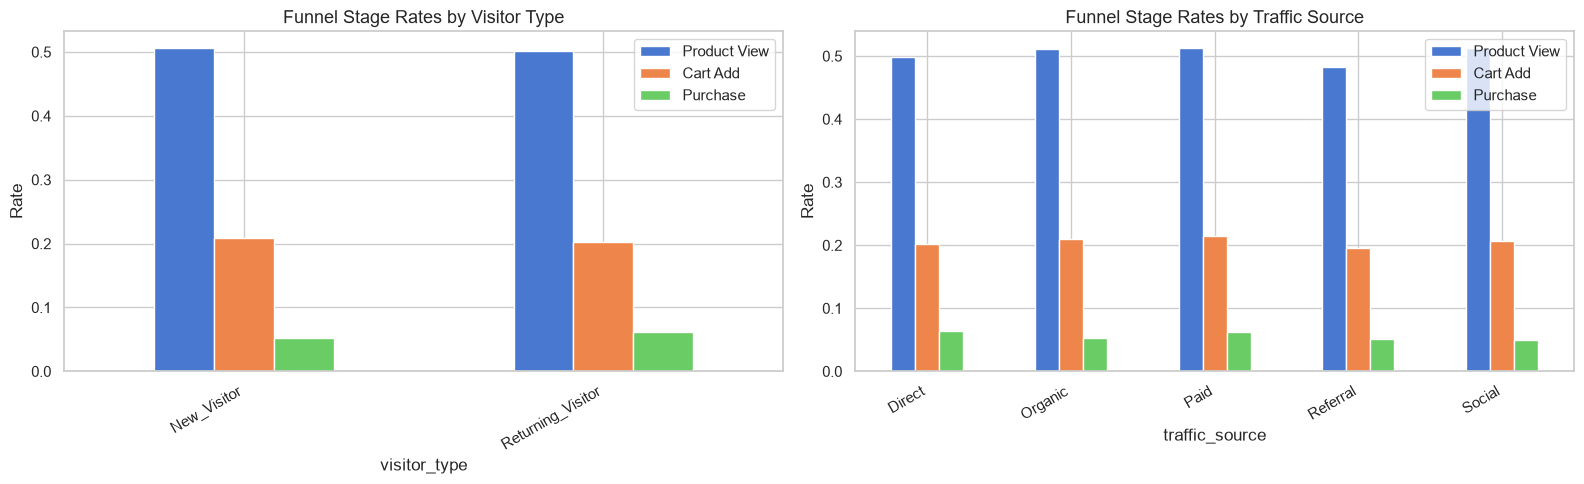

In [12]:
def build_funnel(subset, label):
    t = len(subset)
    vp = (subset['product_pages_viewed'] > 0).sum()
    ac = (subset['cart_additions'] > 0).sum()
    pu = (subset['is_converted'] == 1).sum()
    return {'Segment': label, 'Sessions': t,
            'Viewed Products': vp, '% VP': f"{vp/t*100:.1f}%",
            'Added to Cart': ac, '% Cart': f"{ac/t*100:.1f}%",
            'Purchased': pu, 'Conv Rate': f"{pu/t*100:.2f}%"}

# By visitor type
rows = [build_funnel(df[df['visitor_type'] == vt], vt) for vt in df['visitor_type'].unique()]
vt_funnel = pd.DataFrame(rows)
print("=== Funnel by Visitor Type ===")
print(vt_funnel.to_string(index=False))

# By traffic source
rows = [build_funnel(df[df['traffic_source'] == ts], ts) for ts in df['traffic_source'].unique()]
ts_funnel = pd.DataFrame(rows).sort_values('Sessions', ascending=False)
print("\n=== Funnel by Traffic Source ===")
print(ts_funnel.to_string(index=False))

# Grouped bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, (group_col, title) in zip(axes, [('visitor_type', 'Visitor Type'), ('traffic_source', 'Traffic Source')]):
    grp = df.groupby(group_col).agg(
        pct_product_view=('product_pages_viewed', lambda x: (x > 0).mean()),
        pct_cart_add=('cart_additions', lambda x: (x > 0).mean()),
        pct_purchase=('is_converted', 'mean')
    )
    grp.plot(kind='bar', ax=ax, edgecolor='white')
    ax.set_title(f'Funnel Stage Rates by {title}', fontsize=13)
    ax.set_ylabel('Rate')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
    ax.legend(['Product View', 'Cart Add', 'Purchase'])

plt.tight_layout()
plt.show()

### 3.3 Engagement Score Distribution — Converting vs Non-Converting

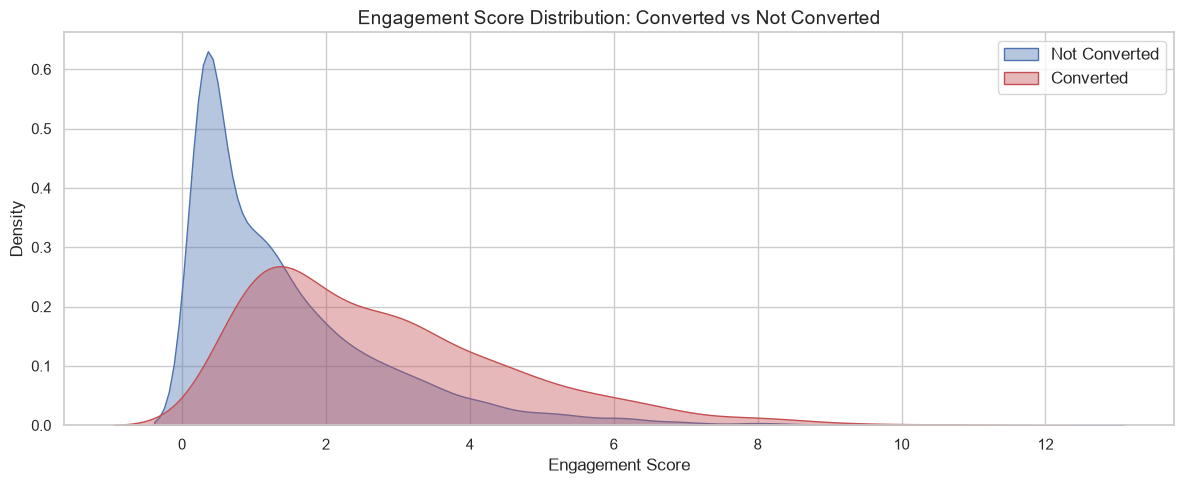

In [13]:
fig, ax = plt.subplots(figsize=(12, 5))
sns.kdeplot(data=df[df['is_converted']==0], x='engagement_score', label='Not Converted', fill=True, alpha=0.4, color='#4C72B0', ax=ax)
sns.kdeplot(data=df[df['is_converted']==1], x='engagement_score', label='Converted', fill=True, alpha=0.4, color='#C44E52', ax=ax)
ax.set_title('Engagement Score Distribution: Converted vs Not Converted', fontsize=14)
ax.set_xlabel('Engagement Score')
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

### 3.4 Notable Observations & Outliers

In [14]:
# High-revenue outliers
high_rev = df[df['revenue'] > df[df['revenue']>0]['revenue'].quantile(0.95)]
print(f"=== Top 5% Revenue Sessions ({len(high_rev)} sessions) ===")
print(f"  Revenue range: ${high_rev['revenue'].min():.2f} - ${high_rev['revenue'].max():.2f}")
print(f"  Avg page views: {high_rev['page_views'].mean():.1f} vs overall {df['page_views'].mean():.1f}")
print(f"  Avg engagement: {high_rev['engagement_score'].mean():.1f} vs overall {df['engagement_score'].mean():.1f}")

# Bounce rate by segment
print(f"\n=== Bounce Rates ===")
for col in ['visitor_type', 'traffic_source', 'device_type']:
    br = df.groupby(col)['bounce'].mean().sort_values(ascending=False)
    print(f"\n  By {col}:")
    for k, v in br.items():
        print(f"    {k}: {v:.1%}")

# Special day effect
special = df[df['is_special_day']==True]['is_converted'].mean()
normal = df[df['is_special_day']==False]['is_converted'].mean()
print(f"\n=== Special Day Effect ===")
print(f"  Special day conversion: {special:.2%}")
print(f"  Normal day conversion:  {normal:.2%}")
print(f"  Lift: {(special/normal - 1)*100:+.1f}%")

=== Top 5% Revenue Sessions (29 sessions) ===
  Revenue range: $112.96 - $413.38
  Avg page views: 5.3 vs overall 3.5
  Avg engagement: 2.7 vs overall 1.5

=== Bounce Rates ===

  By visitor_type:
    Returning_Visitor: 29.6%
    New_Visitor: 28.1%

  By traffic_source:
    Paid: 29.8%
    Referral: 29.6%
    Direct: 28.5%
    Organic: 28.3%
    Social: 28.2%

  By device_type:
    Tablet: 30.2%
    Mobile: 28.5%
    Desktop: 28.5%

=== Special Day Effect ===
  Special day conversion: 5.24%
  Normal day conversion:  5.67%
  Lift: -7.6%


---
## 4. Key Findings & Recommendations

**Key Patterns Observed:**
1. **Returning visitors convert at a higher rate** than new visitors, highlighting the importance of retention strategies.
2. **Paid and Direct traffic** show the highest conversion rates; Social traffic underperforms.
3. **Cart additions are the strongest predictor of purchase** — sessions with even one cart add have dramatically higher conversion.
4. **Desktop users convert slightly more** than mobile/tablet, suggesting potential mobile UX friction.
5. **The biggest funnel drop-off is between "Viewed Product Pages" and "Added to Cart"** — this is the key optimization opportunity.
6. **Engagement score clearly separates** converting and non-converting sessions — it can serve as a real-time scoring signal.
7. **Special/sale days provide a measurable conversion lift**, supporting promotional event strategies.

**Recommendations:**
- Focus UX improvements on the product-to-cart transition (CTAs, trust signals, pricing clarity)
- Invest in retargeting campaigns for returning visitors
- Optimize mobile checkout experience to close the device gap
- Use engagement score as a threshold for triggering real-time offers or chat support
- Increase spend on Paid and Direct traffic channels that show higher ROI